Import necessary Libraries

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score 
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.cluster import KMeans
import streamlit as str


Load DataSet

In [3]:
data=pd.read_csv("C:\\Users\\ASUS\\Desktop\\data_science\\Project\\dataset.csv")
data.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


Data Info

In [4]:
data.info()
 

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

Data Understanding


In [5]:
data.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


Data Cleaning 

In [6]:
data.isnull().sum()
data.drop_duplicates()
data.dropna(inplace=True)

Feature Engineering

In [7]:
data['trending']=data['popularity'].apply(lambda x:1 if x>70 else 0 ) 
features=['tempo','popularity','energy','loudness','danceability',
          'valence','acousticness','instrumentalness','speechiness']

Data Visualization

1.Popularity Distribution

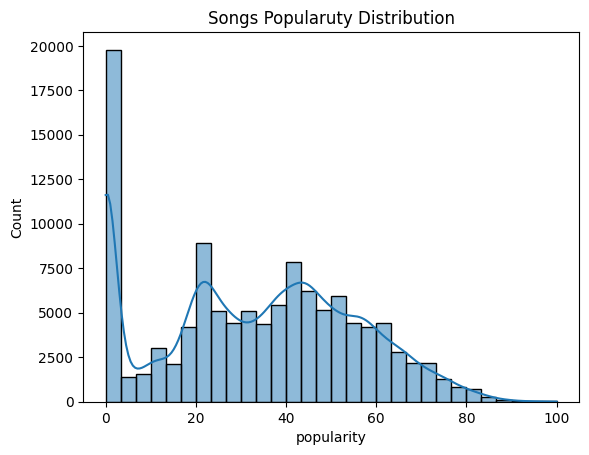

In [8]:
sns.histplot(data['popularity'],bins=30,kde=True)
plt.title("Songs Popularuty Distribution")
plt.show()

Text(0.5, 1.0, 'Top Genre Distribution')

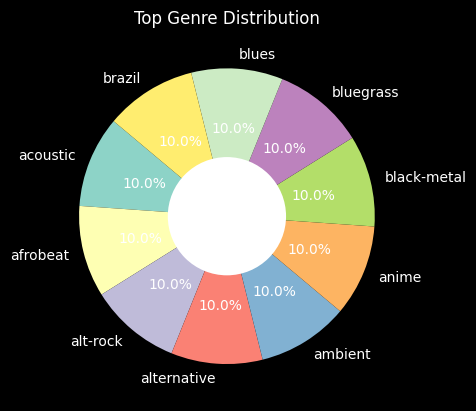

In [9]:
plt.style.use('dark_background')
top_genres=data['track_genre'].value_counts().head(10)
plt.pie(top_genres,labels=top_genres.index,autopct='%1.1f%%',startangle=140)
centre_circle=plt.Circle((0,0),0.40,fc='white')
fig=plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title("Top Genre Distribution")
 

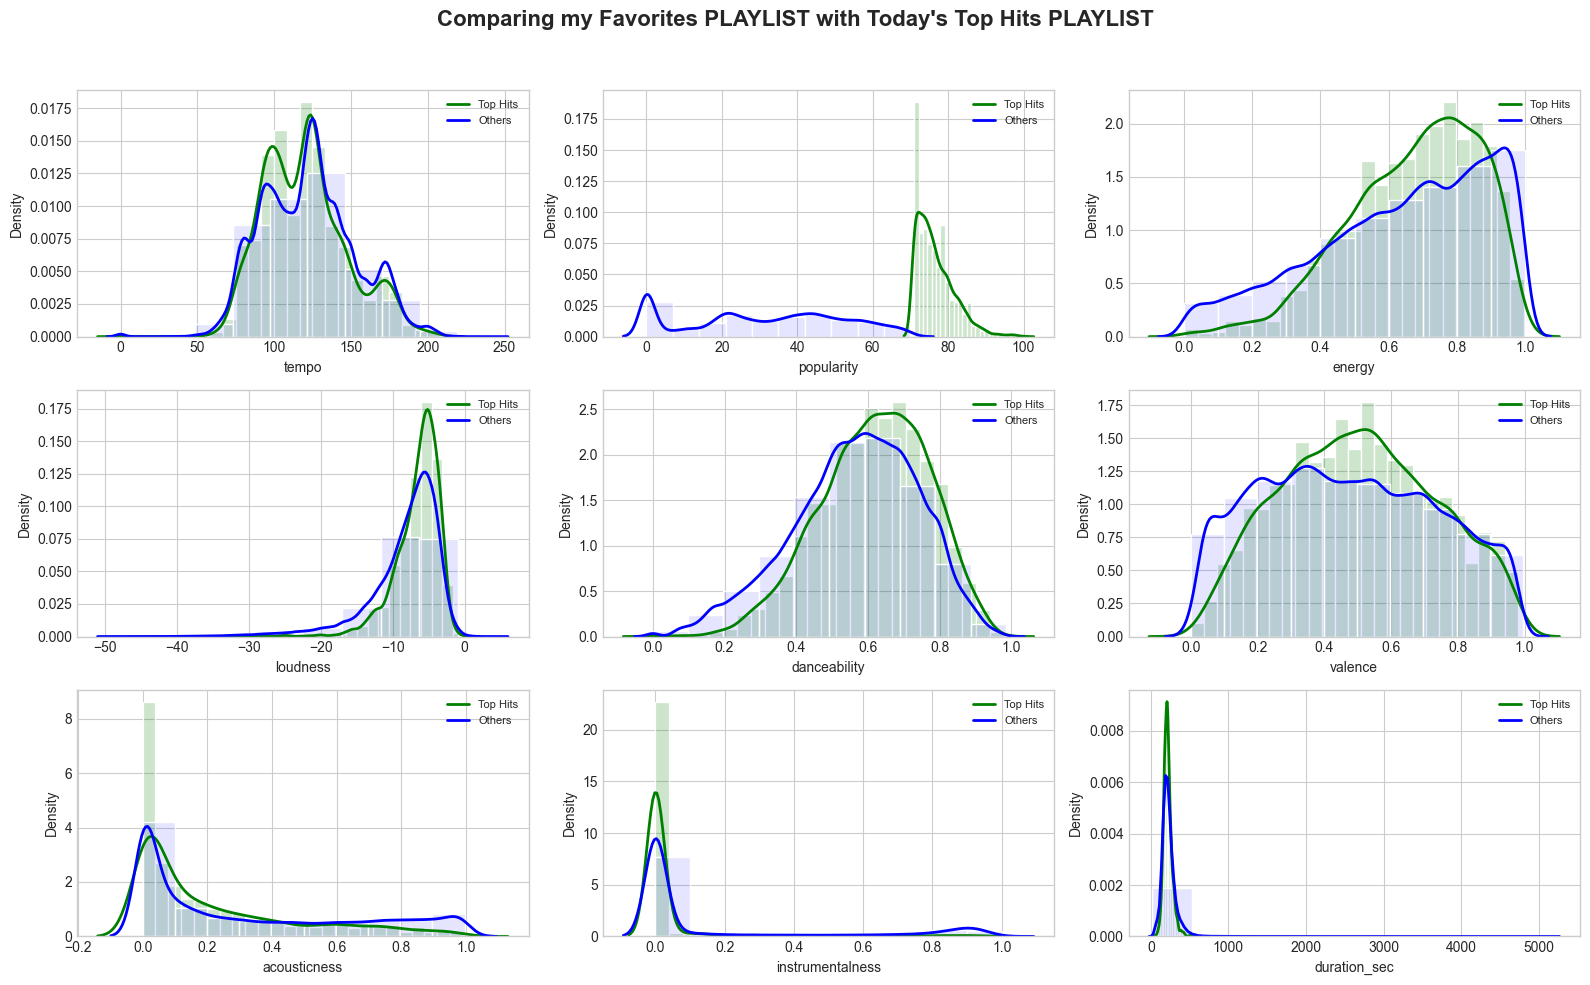

In [ ]:
 
 
plt.style.use('seaborn-v0_8-whitegrid')

 
top_hits = data[data['popularity'] > 70]
low_hits = data[data['popularity'] <= 70]
 
titles = ['Tempo','Popularity','Energy',
          'Loudness','Danceability','Valence (positive mood)',
          'Acousticness','Release Year','Song Duration (sec)']

 
data['duration_sec'] = data['duration_ms'] / 1000
top_hits['duration_sec'] = top_hits['duration_ms'] / 1000
low_hits['duration_sec'] = low_hits['duration_ms'] / 1000

 
features[-1] = 'duration_sec'

 
fig, axes = plt.subplots(3, 3, figsize=(16,10))
axes = axes.flatten()

for i, col in enumerate(features):
    
   
    sns.histplot(top_hits[col],
                 ax=axes[i],
                 color='green',
                 bins=25,
                 stat='density',
                 alpha=0.20)

    sns.histplot(low_hits[col],
                 ax=axes[i],
                 color='blue',
                 bins=10,
                 stat='density',
                 alpha=0.10)

 
    sns.kdeplot(top_hits[col], ax=axes[i], color='green', linewidth=2)
    sns.kdeplot(low_hits[col], ax=axes[i], color='blue', linewidth=2)

 
    
    axes[i].set_xlabel(col)
 

     
    axes[i].legend(['Top Hits', 'Others'], fontsize=8)
 
fig.suptitle("Comparing my Favorites PLAYLIST with Today's Top Hits PLAYLIST",
             fontsize=16, fontweight='bold')

 
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

2.Correlation Heatmap

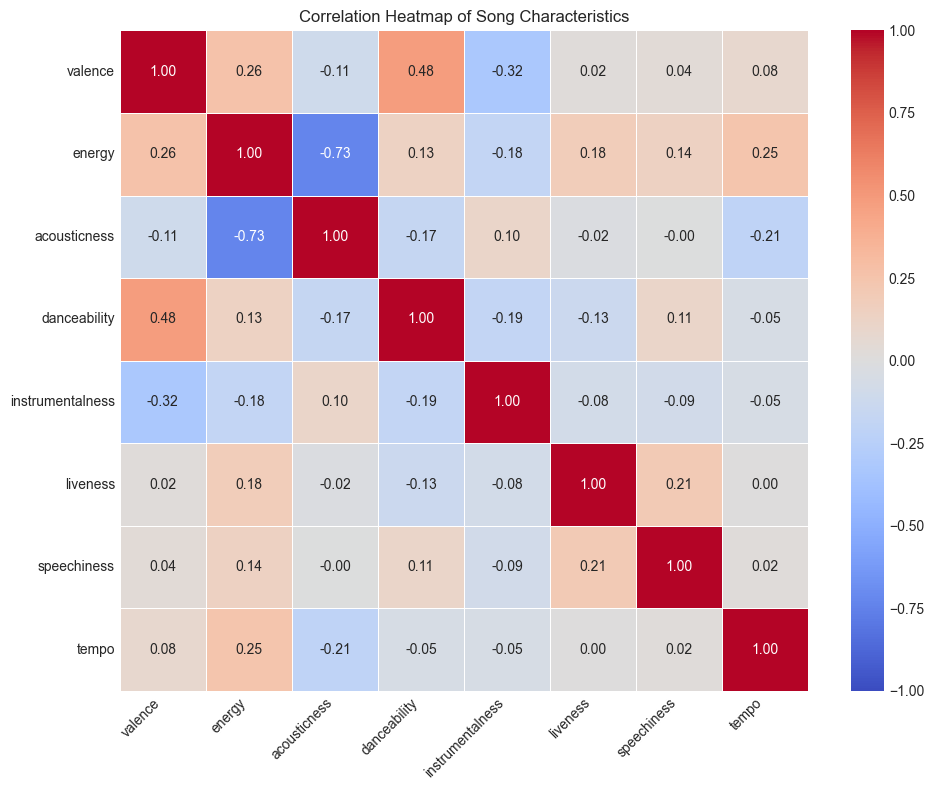

In [11]:
plt.figure(figsize=(10, 8))

features = [
    'valence',
    'energy',
    'acousticness',
    'danceability',
    'instrumentalness',
    'liveness',
    'speechiness',
    'tempo'        
]    

X = data[features].corr()  # ✅ fixed

sns.heatmap(X, annot=True, cmap='coolwarm', fmt='.2f', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white', annot_kws={'size': 10})

plt.title("Correlation Heatmap of Song Characteristics")
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

3.Genre VS Feature

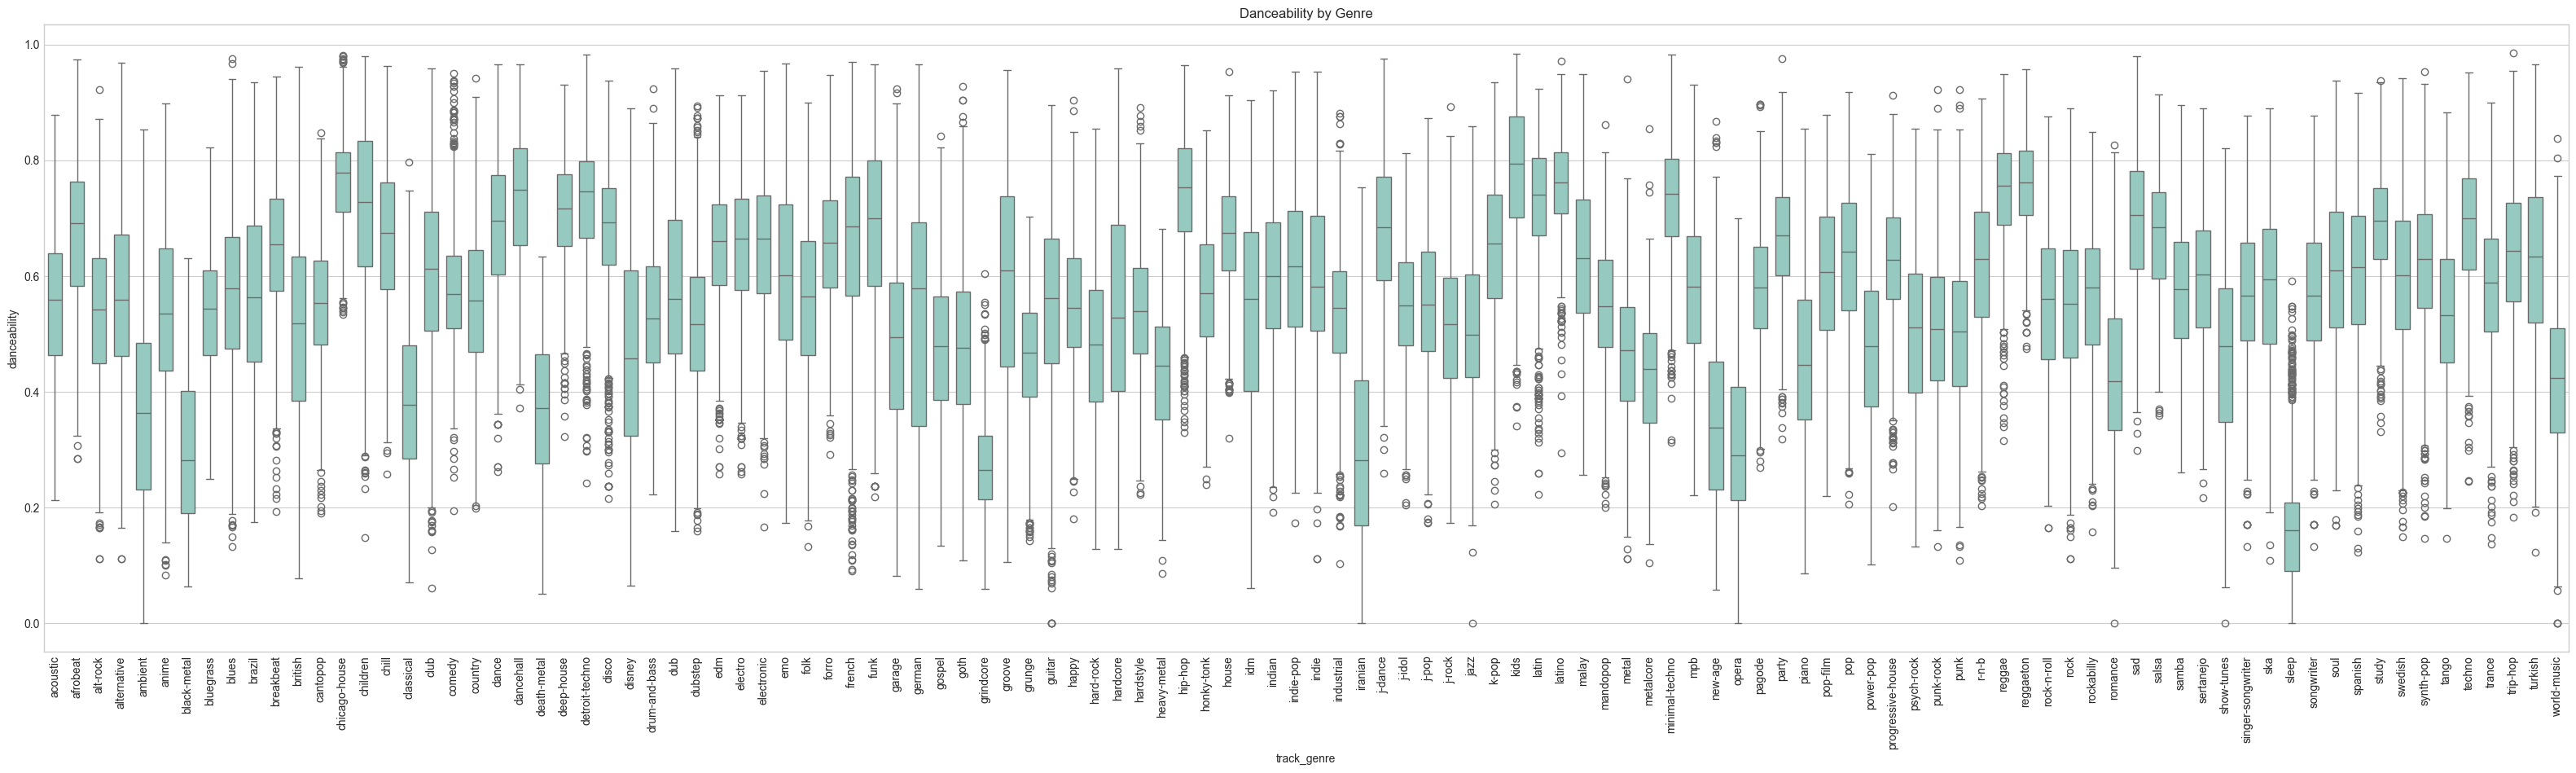

In [12]:
plt.figure(figsize=(40,10))
sns.boxplot(x='track_genre',y='danceability',data=data,gap=0.20)
plt.xticks(rotation=90 )
plt.title("Danceability by Genre")
plt.show()


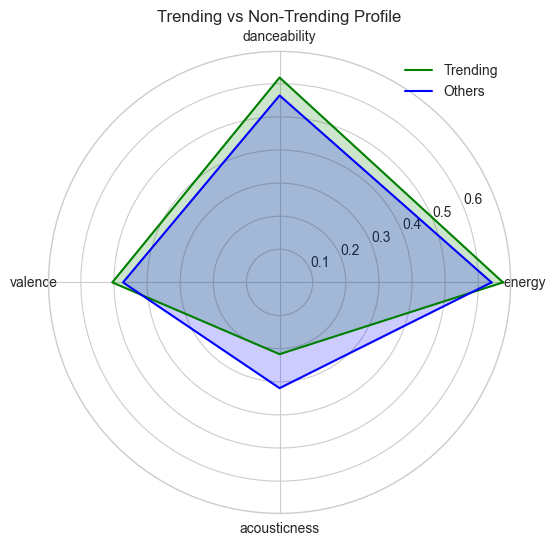

In [13]:
 

features = ['energy','danceability','valence','acousticness']

# Split trending vs non-trending
top_mean = data[data['trending']==1][features].mean()
low_mean = data[data['trending']==0][features].mean()

angles = np.linspace(0, 2*np.pi, len(features), endpoint=False)

# ✅ Use .values to avoid KeyError
top = np.concatenate((top_mean.values, [top_mean.values[0]]))
low = np.concatenate((low_mean.values, [low_mean.values[0]]))
angles = np.concatenate((angles, [angles[0]]))

# Plot radar
plt.figure(figsize=(6,6))
plt.polar(angles, top, label='Trending', color='green')
plt.polar(angles, low, label='Others', color='blue')

plt.fill(angles, top, alpha=0.2, color='green')
plt.fill(angles, low, alpha=0.2, color='blue')

plt.xticks(angles[:-1], features)
plt.legend()
plt.title("Trending vs Non-Trending Profile")
plt.show()

Key Insights

High energy + danceability → more popular songs

Acoustic songs are less trending

Genres like pop/edm have higher popularity

Loudness and tempo impact engagement

Prepare Data

In [14]:
x=data[['danceability','energy','loudness','speechiness','acousticness','instrumentalness','valence','tempo']]
y=data['trending']
x_train, x_test, y_train, y_test =train_test_split(x,y,test_size=0.2,random_state=42)

Train Model

1.Random Forest Classification

In [15]:
model=RandomForestClassifier()
model.fit(x_train,y_train)
pred=model.predict(x_test)
accuracy =accuracy_score(y_test,pred)
accuracy

0.9810087719298246

2.Decision Tree

In [22]:
model=DecisionTreeClassifier()
model.fit(x_train,y_train)
pred=model.predict(x_test)
accuracy=accuracy_score(y_test,pred)
accuracy

0.9603508771929825

3.Logistic Regression

In [27]:
model=LogisticRegression(max_iter=5000)
model.fit(x_train,y_train)
pred=model.predict(x_test)
accuracy=accuracy_score(y_test,pred)
accuracy

0.9587280701754386

Feature Importance

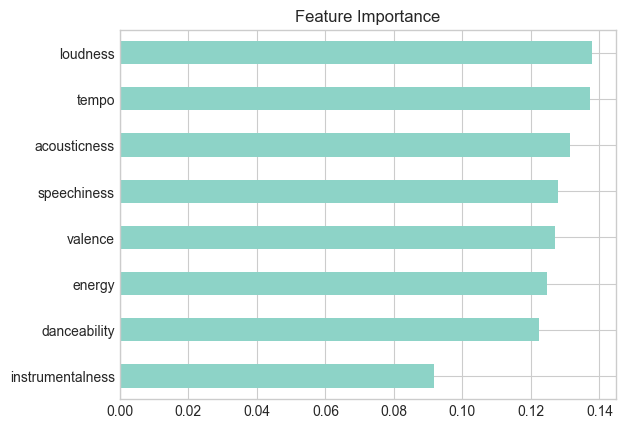

In [16]:
importance=pd.Series(model.feature_importances_,index=x.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

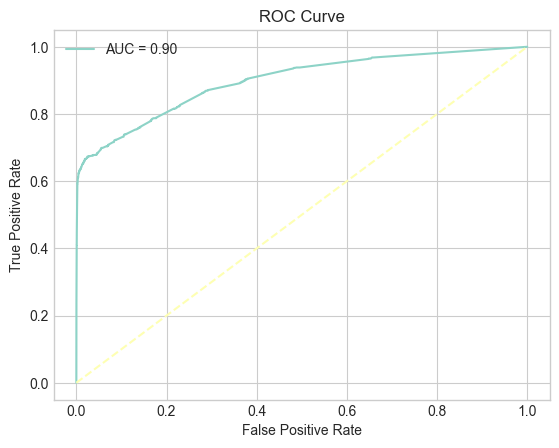

In [20]:
 

y_prob = model.predict_proba(x_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

Clustering

In [31]:
kmeans=KMeans(n_clusters=3)
data['cluster']=kmeans.fit_predict(x)